Basic ChatBot with langGraph(GRAPH API)

In [30]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [31]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [32]:
graph_builder

In [33]:
import os
from dotenv import load_dotenv
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [34]:
from dotenv import load_dotenv
load_dotenv()

import os
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY")
)

In [35]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002142F69C1D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002142F68E9D0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [36]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002142F69A1D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002142F645390>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [37]:
##Node functionality

def chatbot(state:State):
    return{"messages":[llm.invoke(state["messages"])]}

In [38]:
graph_builder = StateGraph(State)

## adding nodes to the graph
graph_builder.add_node("llmchatbot",chatbot)

## adding edges to the graph
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

##compile the graph
graph = graph_builder.compile()

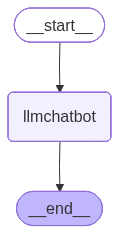

In [39]:
##visualization
from IPython.display import display,Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred while visualizing the graph: {e}")

In [40]:
response = graph.invoke({"messages":"Hello, how are you?"})

In [41]:
response["messages"][-1].content

"I'm functioning properly, thank you for asking."

In [42]:
for event in graph.stream({"messages":"hello how is the weather in banglore"}):
     for value in event.values():
       print(value["messages"][-1].content)

Unfortunately, I'm a large language model, I don't have real-time access to current weather conditions. However, I can suggest some ways for you to get the current weather in Bangalore.

You can:

1. Check online weather websites such as AccuWeather, Weather.com, or the Indian Meteorological Department (IMD) website for the current weather conditions in Bangalore.
2. Use a weather app on your smartphone, such as Dark Sky or Weather Underground, to get the current weather conditions and forecast in Bangalore.
3. Tune into local news or weather channels to get the current weather conditions and forecast in Bangalore.

If you want, I can provide you with the typical weather conditions in Bangalore during different times of the year. Bangalore has a humid subtropical climate with three main seasons:

* Summer (March to May): Hot and dry with temperatures ranging from 25°C to 35°C (77°F to 95°F).
* Monsoon (June to September): Humid with heavy rainfall and temperatures ranging from 20°C to 

ChatBot with Tools

In [43]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("what is langchain?")


{'query': 'what is langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/langchain',
   'title': 'What is LangChain? - AWS',
   'content': 'LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new prompt chains or customize existing templates. To do that, machine learning engineers must integrate the LLM with the organization’s internal data sources and apply *prompt engineering*—a practice where a data scientist refines inputs to a generative model with a specific structure and 

In [44]:
##custom function

def multiply(a:int,b:int)->int:
    """multiply a and b
    args:
    a(int): first
    b(int): second

    returns:
    int:output first
    """
    return a*b

In [45]:
tools = [tool,multiply]

In [46]:
llm_with_tools = llm.bind_tools(tools)

In [47]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002142F69A1D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002142F645390>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [48]:
## stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition

##node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}
##graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

## compile the graph
graph = builder.compile()



In [ ]:
response= graph.invoke({"messages":"what is recent ai news?"})

In [ ]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/24/companies-are-scrambling-to-stop-employees-from-maxing-out-ai-budgets-with-small-tasks/", "title": "Companies are scrambling to stop employees from maxing out AI budgets with small tasks - TechCrunch", "score": 0.8051581, "published_date": "Wed, 24 Jun 2026 20:09:45 GMT", "content": "Founder Summit ticket savings of up to $190 end June 26. After the AI industry encouraged companies to max out their AI budgets earlier this year, and some companies even built employee leaderboards to encourage internal AI usage — they are now realizing just how easy it is to spend huge sums of money on AI and get little in return. Recent news has been rife with stories about AI cutbacks and now 404 Media reports that consulting firm Accenture has been attempting to stop its employees from depleting its token reserves by using AI to do basic tasks — like converting

In [ ]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (7qpatkcy5)
 Call ID: 7qpatkcy5
  Args:
    query: recent AI news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/24/companies-are-scrambling-to-stop-employees-from-maxing-out-ai-budgets-with-small-tasks/", "title": "Companies are scrambling to stop employees from maxing out AI budgets with small tasks - TechCrunch", "score": 0.8051581, "published_date": "Wed, 24 Jun 2026 20:09:45 GMT", "content": "Founder Summit ticket savings of up to $190 end June 26. After the AI industry encouraged companies to max out their AI budgets earlier this year, and some companies even bui

In [ ]:
response= graph.invoke({"messages":"what is 2 multiplied by 3?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (67zghgsx8)
 Call ID: 67zghgsx8
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


ReAct Agent Architecture

In [57]:
from dotenv import load_dotenv
load_dotenv()

from typing import Annotated
from typing_extensions import TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# ----------------------------
# Initialize LLM
# ----------------------------
llm = init_chat_model("groq:llama-3.1-8b-instant")

# ----------------------------
# State
# ----------------------------
class State(TypedDict):
    messages: Annotated[list, add_messages]

# ----------------------------
# Tool 1 : Tavily Search
# ----------------------------
search = TavilySearch(max_results=2)

# ----------------------------
# Tool 2 : Multiply
# ----------------------------
@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Product of a and b
    """
    return a * b

# ----------------------------
# List of Tools
# ----------------------------
tools = [search, multiply]

# Bind tools with LLM
llm_with_tools = llm.bind_tools(tools)

# ----------------------------
# LLM Node
# ----------------------------
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tools.invoke(state["messages"])
        ]
    }

# ----------------------------
# Build Graph
# ----------------------------
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# Compile Graph
graph = builder.compile()

# ----------------------------
# Run ReAct Agent
# ----------------------------
query = "Give me the recent AI news and also multiply 5 by 5."

response = graph.invoke(
    {
        "messages": [
            HumanMessage(content=query)
        ]
    }
)

# ----------------------------
# Print Conversation
# ----------------------------
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Give me the recent AI news and also multiply 5 by 5.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ekn5etwmw)
 Call ID: ekn5etwmw
  Args:
    query: AI news
    start_date: 2024-01-01
    topic: news
  multiply (27r5gbxdp)
 Call ID: 27r5gbxdp
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2025/01/08/this-week-in-ai-more-capable-ai-is-coming-but-will-its-benefits-be-evenly-distributed/", "title": "This Week in AI: More capable AI is coming, but will its benefits be evenly distributed? - TechCrunch", "score": 0.65252984, "published_date": "Wed, 08 Jan 2025 18:05:00 GMT", "content": "AI AI AI Hiya, folks, welcome to TechCrunch’s regular AI news

adding memory in agentic graph